# Correlation and Feature Importance Analysis

**Purpose**: Comprehensive analysis of feature relationships and predictive power for configuration file recommendation.

**Dataset**: 1,465 repositories $\times$ 32 features (27 numeric + 5 boolean) $\times$ 10 labels (multi-label)

**Analyses**:
1. Feature-feature correlations 
2. Feature-label correlations 
3. Label-label correlations (Configuration Co-occurrence)

## Setup and Imports

In [43]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency, pearsonr, pointbiserialr

from src.utils import load_latest_dataset, print_dataset_schema

In [44]:
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["font.size"] = 11
plt.rcParams["savefig.format"] = "pdf"
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["savefig.dpi"] = 300

### Output files directories creation

In [45]:
artifacts_dir = Path("artifacts")

corr_dir = artifacts_dir / "correlation"
corr_dir.mkdir(parents=True, exist_ok=True)

## Data Loading and Validation

In [46]:
df, manifest, version_path = load_latest_dataset(data_dir="../data/processed")


Dataset loaded: 1465 records
  Version: 1.0.1
  Created: 2026-04-01T19:45:24.483060+00:00
  Git commit: 4f490c29


In [47]:
label_cols = [
    "has_pyproject_toml",
    "has_dockerfile",
    "has_github_actions",
    "has_tox_ini",
    "has_conda_env_file",
    "has_docker_compose",
    "has_precommit_config",
    "has_setup_py",
    "has_requirements_txt",
    "has_makefile",
]

schema = print_dataset_schema(df, label_cols)


id_col = schema["id_col"]
label_cols = schema["label_cols"]
feature_cols = schema["feature_cols"]

Dataset Schema:
  Total columns: 43
  Identifier: 1 (repo_url)
  Features: 32
  Labels: 10


## 1. Feature-Feature Correlation Matrix

**Method**: Pearson correlation coefficient with statistical significance testing

**Interpretation**: 
- **r close to 1 or -1**: Strong linear relationship
- **r close to 0**: Weak or no linear relationship
- **p-value < 0.05**: Statistically significant correlation (not due to random chance)
- **p-value ≥ 0.05**: Not statistically significant (could be random noise)

Computing p-values for feature-feature correlations...


Correlation matrix is valid (no NaN/inf values)

Exported: artifacts/correlation/feature_feature_corr.csv
Exported: artifacts/correlation/feature_feature_pvalues.csv

High correlations detected (|r| > 0.6):
  stars - forks: r = 0.875, p = 0.000
  num_files - other_extensions_count: r = 0.819, p = 0.000
  num_files - num_dirs: r = 0.731, p = 0.000
  num_py_files - num_test_files: r = 0.674, p = 0.000
  num_files - num_py_files: r = 0.619, p = 0.000
  num_py_files - num_dirs: r = 0.612, p = 0.000


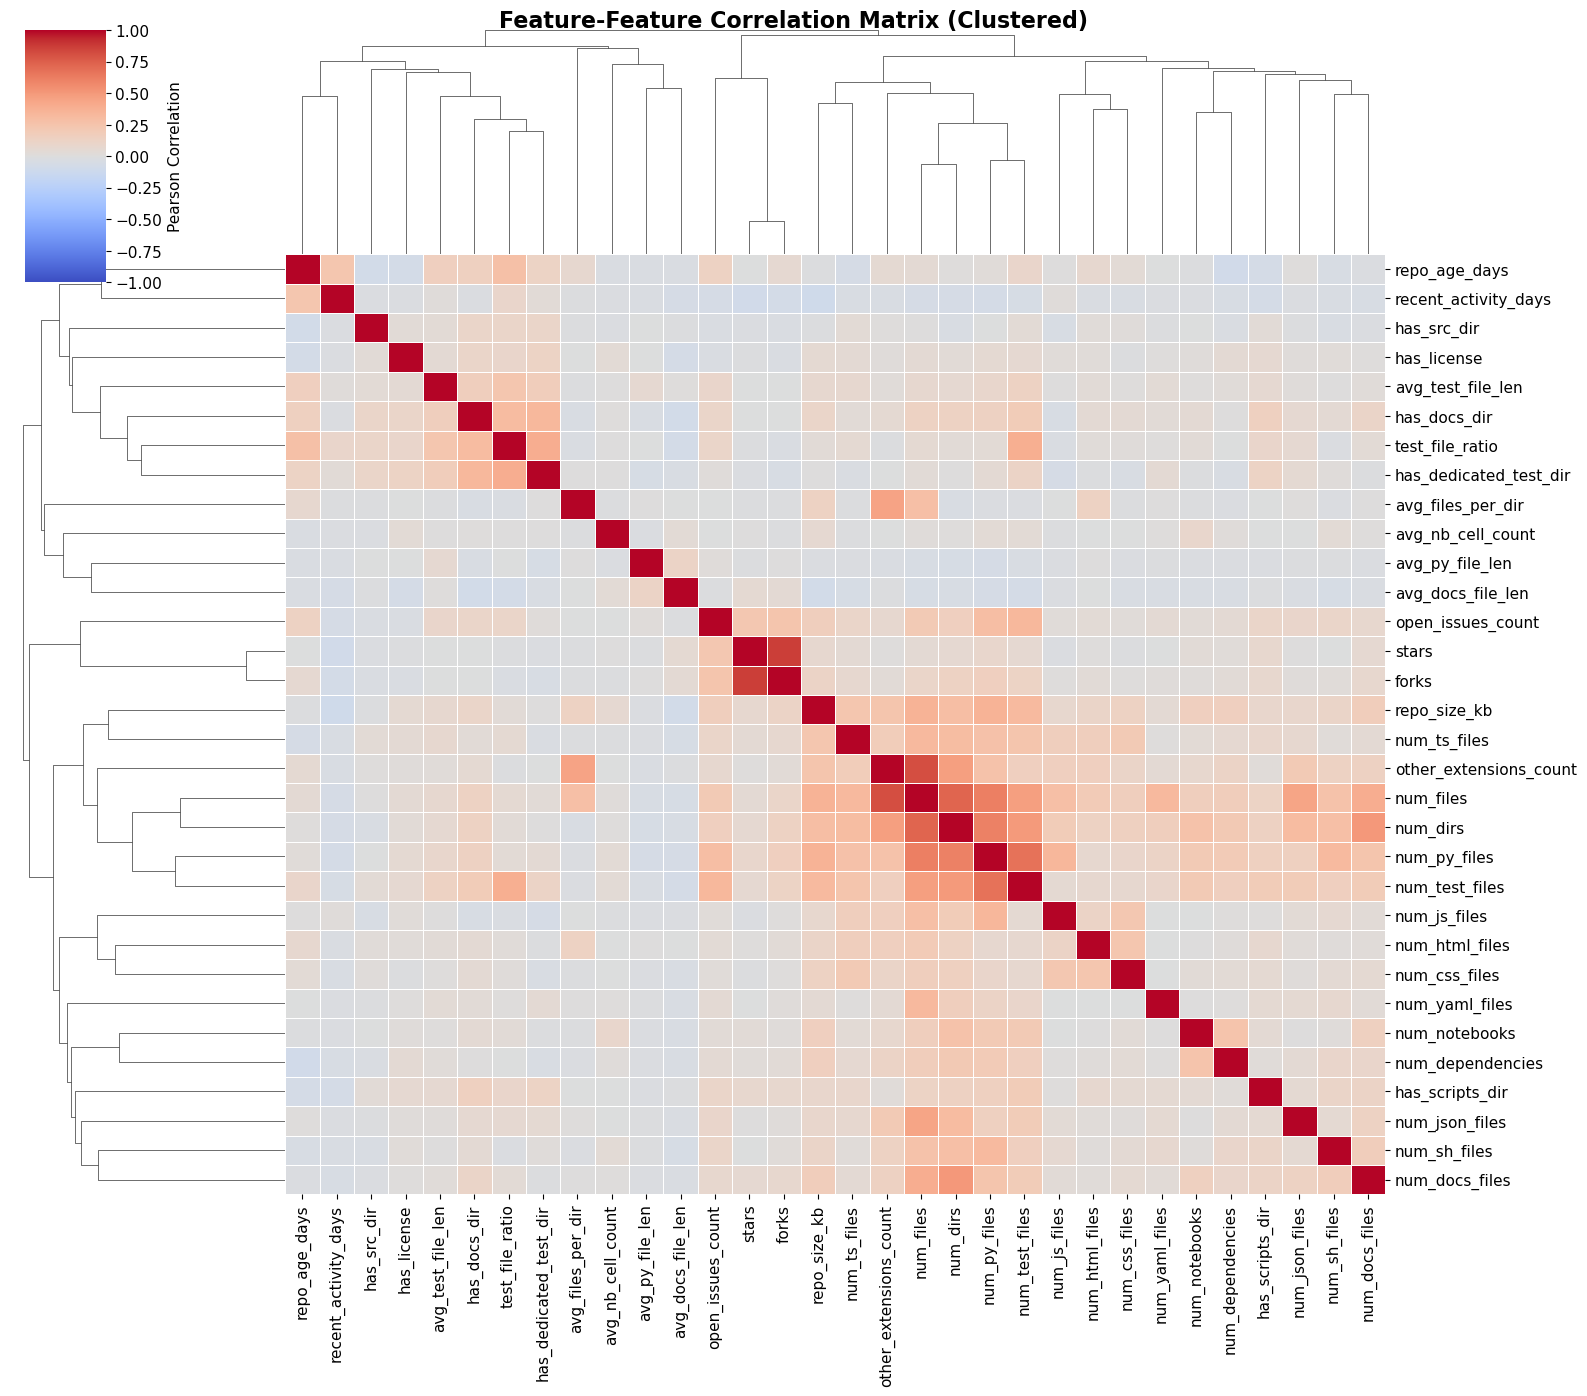

Exported: artifacts/correlation/feature_feature_heatmap.pdf


In [48]:
corr_matrix = df[feature_cols].corr(method="pearson")

# P-value computing
print("Computing p-values for feature-feature correlations...")
n_features = len(feature_cols)
pvalue_matrix = pd.DataFrame(
    np.ones((n_features, n_features)), index=feature_cols, columns=feature_cols
)

for i in range(n_features):
    for j in range(i + 1, n_features):
        feat1, feat2 = feature_cols[i], feature_cols[j]

        mask = df[feat1].notna() & df[feat2].notna()
        x = df.loc[mask, feat1]
        y = df.loc[mask, feat2]

        if len(x) > 2:
            _, p_val = pearsonr(x, y)
            pvalue_matrix.iloc[i, j] = p_val
            pvalue_matrix.iloc[j, i] = p_val

if corr_matrix.isnull().any().any() or np.isinf(corr_matrix.values).any():
    print("Warning: Correlation matrix contains NaN/inf values")

    problematic_features = corr_matrix.columns[corr_matrix.isnull().any()].tolist()
    if problematic_features:
        print(f"   Problematic features: {problematic_features}")

    corr_matrix_clean = corr_matrix.fillna(0).replace([np.inf, -np.inf], 0)
else:
    corr_matrix_clean = corr_matrix
    print("Correlation matrix is valid (no NaN/inf values)")

export_path = corr_dir / "feature_feature_corr.csv"
corr_matrix.to_csv(export_path)
print(f"\nExported: {export_path}")

export_path_pval = corr_dir / "feature_feature_pvalues.csv"
pvalue_matrix.to_csv(export_path_pval)
print(f"Exported: {export_path_pval}")

high_corr_threshold = 0.6
significance_level = 0.05

high_corr = []

for i in range(len(corr_matrix_clean.columns)):
    for j in range(i + 1, len(corr_matrix_clean.columns)):
        corr_val = corr_matrix_clean.iloc[i, j]
        p_val = pvalue_matrix.iloc[i, j]

        if not np.isnan(corr_val) and abs(corr_val) > high_corr_threshold:
            high_corr.append(
                (
                    corr_matrix_clean.columns[i],
                    corr_matrix_clean.columns[j],
                    corr_val,
                    p_val,
                )
            )

if high_corr:
    print(f"\nHigh correlations detected (|r| > {high_corr_threshold}):")
    for feat1, feat2, corr, pval in sorted(
        high_corr, key=lambda x: abs(x[2]), reverse=True
    ):
        print(f"  {feat1} - {feat2}: r = {corr:.3f}, p = {pval:.3f}")
else:
    print(f"\n No high correlations (all |r| < {high_corr_threshold})")

export_path = corr_dir / "feature_feature_heatmap.pdf"

g = sns.clustermap(
    corr_matrix_clean,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=False,
    linewidths=0.5,
    cbar_kws={"label": "Pearson Correlation"},
    figsize=(16, 14),
)
g.fig.suptitle(
    "Feature-Feature Correlation Matrix (Clustered)",
    y=0.995,
    fontsize=16,
    fontweight="bold",
)
plt.savefig(export_path, format="pdf", bbox_inches="tight")
plt.show()

print(f"Exported: {export_path}")

## 2. Feature-Label Correlations

**Purpose**: Identify which features are most predictive of each configuration file type.

**Method**: Point-biserial correlation (continuous feature with binary label)

**Interpretation**:
- Positive correlation: Higher feature value higher likelyhood of having that config file
- Negative correlation: Higher feature value lower likelyhood of having that config file
- |r| > 0.3: Moderate predictive power
- |r| > 0.5: Strong predictor

Exported: artifacts/correlation/feature_label_corr.csv


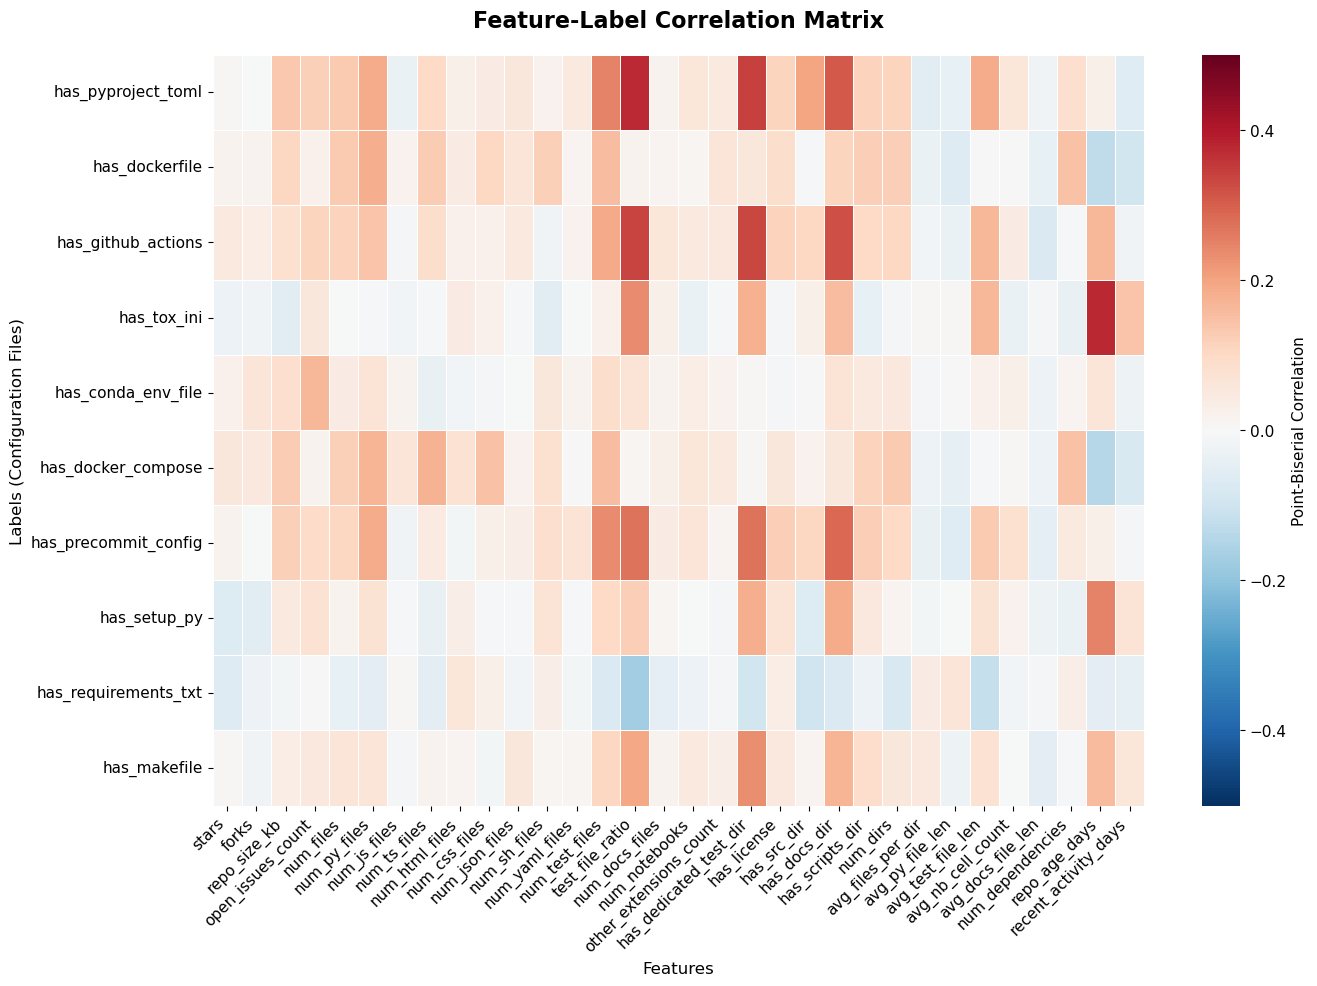

Exported: artifacts/correlation/feature_label_heatmap.pdf


In [49]:
feature_label_corr = pd.DataFrame(index=feature_cols, columns=label_cols)

for feature in feature_cols:
    for label in label_cols:
        if df[label].nunique() < 2:
            feature_label_corr.loc[feature, label] = np.nan
        else:
            corr, _ = pointbiserialr(df[label], df[feature])
            feature_label_corr.loc[feature, label] = corr

feature_label_corr = feature_label_corr.astype(float)
export_path = corr_dir / "feature_label_corr.csv"

feature_label_corr.to_csv(export_path)
print(f"Exported: {export_path}")

export_path = corr_dir / "feature_label_heatmap.pdf"

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    feature_label_corr.T,
    cmap="RdBu_r",
    center=0,
    vmin=-0.5,
    vmax=0.5,
    annot=False,
    linewidths=0.5,
    cbar_kws={"label": "Point-Biserial Correlation"},
    ax=ax,
)
ax.set_title("Feature-Label Correlation Matrix", fontsize=16, fontweight="bold", pad=20)
ax.set_xlabel("Features", fontsize=12)
ax.set_ylabel("Labels (Configuration Files)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(export_path, format="pdf", bbox_inches="tight")
plt.show()

print(f"Exported: {export_path}")

In [50]:
print("Top 5 Most Correlated Features per Label:")
for label in label_cols:
    print(f"\n{label}:")
    top = feature_label_corr[label].abs().sort_values(ascending=False).head(5)
    for rank, (feature, _) in enumerate(top.items(), 1):
        actual_corr = feature_label_corr.loc[feature, label]
        print(f"  {rank}. {feature}: r = {actual_corr:.3f}")

Top 5 Most Correlated Features per Label:

has_pyproject_toml:
  1. test_file_ratio: r = 0.374
  2. has_dedicated_test_dir: r = 0.341
  3. has_docs_dir: r = 0.307
  4. num_test_files: r = 0.250
  5. has_src_dir: r = 0.199

has_dockerfile:
  1. num_py_files: r = 0.182
  2. num_test_files: r = 0.153
  3. num_dependencies: r = 0.146
  4. num_files: r = 0.133
  5. repo_age_days: r = -0.126

has_github_actions:
  1. test_file_ratio: r = 0.337
  2. has_dedicated_test_dir: r = 0.334
  3. has_docs_dir: r = 0.323
  4. num_test_files: r = 0.191
  5. avg_test_file_len: r = 0.168

has_tox_ini:
  1. repo_age_days: r = 0.378
  2. test_file_ratio: r = 0.236
  3. has_dedicated_test_dir: r = 0.176
  4. avg_test_file_len: r = 0.167
  5. has_docs_dir: r = 0.152

has_conda_env_file:
  1. open_issues_count: r = 0.165
  2. num_test_files: r = 0.086
  3. repo_size_kb: r = 0.083
  4. has_docs_dir: r = 0.068
  5. num_py_files: r = 0.067

has_docker_compose:
  1. num_ts_files: r = 0.173
  2. num_py_files: r = 0

## 3. Label-Label Correlations (Configuration Co-occurrence)

Analyze which configuration files tend to appear together using Cramér's V for binary variables.

**Interpretation** (Cohen, 1988):
- **0.0 - 0.1**: Negligible association
- **0.1 - 0.3**: Weak association
- **0.3 - 0.5**: Moderate association
- **> 0.5**: Strong association

Exported: artifacts/correlation/label_label_corr.csv


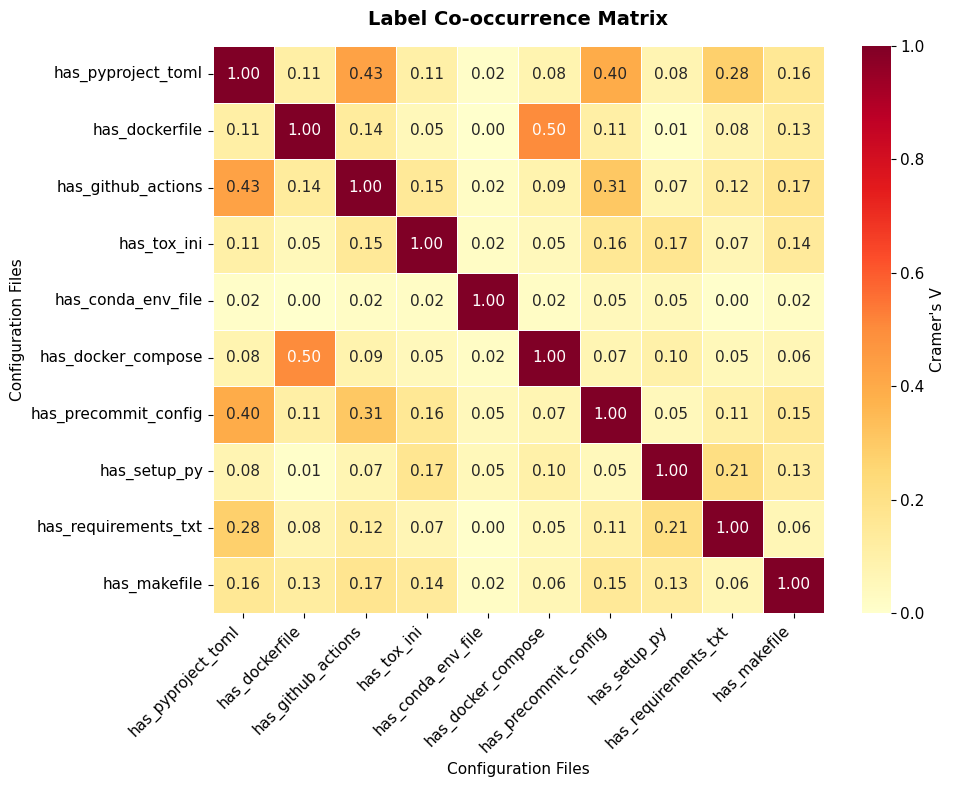

Exported: artifacts/correlation/label_label_heatmap.pdf


In [51]:
def cramers_v(x: pd.Series, y: pd.Series) -> float:
    """Calculate Cramer's V statistic for categorical association."""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    return np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0


label_label_corr = pd.DataFrame(index=label_cols, columns=label_cols)

for i, label1 in enumerate(label_cols):
    for j, label2 in enumerate(label_cols):
        if i == j:
            label_label_corr.loc[label1, label2] = 1.0
        elif i > j:
            label_label_corr.loc[label1, label2] = label_label_corr.loc[label2, label1]
        else:
            label_label_corr.loc[label1, label2] = cramers_v(df[label1], df[label2])

label_label_corr = label_label_corr.astype(float)

export_path = corr_dir / "label_label_corr.csv"
label_label_corr.to_csv(export_path)
print(f"Exported: {export_path}")

export_path = corr_dir / "label_label_heatmap.pdf"
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    label_label_corr,
    cmap="YlOrRd",
    vmin=0,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Cramer's V"},
    ax=ax,
)
ax.set_title("Label Co-occurrence Matrix", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Configuration Files", fontsize=11)
ax.set_ylabel("Configuration Files", fontsize=11)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(export_path, format="pdf", bbox_inches="tight")
plt.show()
print(f"Exported: {export_path}")